In [75]:
import pandas as pd
import plotnine as p9
import numpy as np

Concept of reverse causality - Mixing up cause and effect


In [44]:
coffee_dt = pd.read_csv("./coffee_sim.csv")
coffee_dt.describe()
coffee_dt.groupby('coffee_cups_per_day').describe()


cigarette_packs_per_day                                \
                                      count      mean       std  min  25%   
coffee_cups_per_day                                                         
0                                    1136.0  0.251761  0.500217  0.0  0.0   
1-5                                  1173.0  0.989770  0.679965  0.0  1.0   
5+                                    691.0  1.606368  0.600642  0.0  1.0   

                                   datavizitis_deaths_per_thousand             \
                     50%  75%  max                           count       mean   
coffee_cups_per_day                                                             
0                    0.0  0.0  2.0                          1136.0   5.740130   
1-5                  1.0  1.0  2.0                          1173.0   9.661406   
5+                   2.0  2.0  2.0                           691.0  13.216582   

                                                                          \
                          std       min        25%        50%        75%   
coffee_cups_per_day                                                        
0                    2.772715  1.329574   3.980798   4.829979   6.268509   
1-5                  3.862171  1.864252   7.482661   9.463669  11.088627   
5+                   3.541279  2.948488  10.058135  14.782081  15.771534   

                                
                           max  
coffee_cups_per_day             
0                    16.893181  
1-5                  17.863872  
5+                   18.435658

1. Suggest an appropriate visualization and implement it with plotnine to display a possible association
between coffee consumption and “datavizitis” disease risk, measured in deaths per 1000 individuals. Does
this plot by itself seem consistent with a causal effect of coffee on datavizitis?

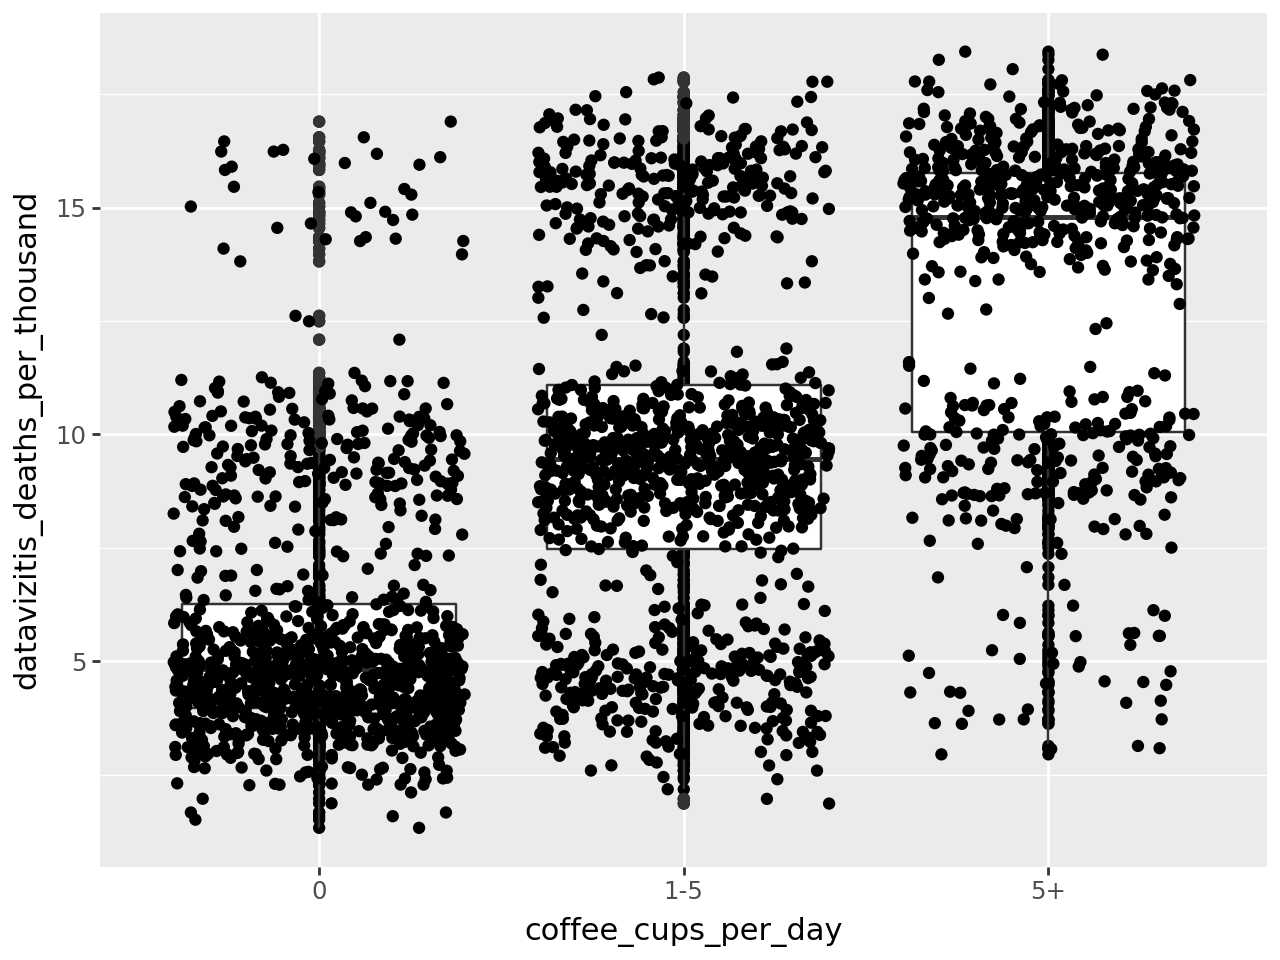

In [46]:
ggplot(coffee_dt, aes(y="datavizitis_deaths_per_thousand", x="coffee_cups_per_day")) + geom_point() + geom_boxplot() + geom_jitter()

2. Investigate the full dataset. Do you see evidence for a third variable influencing association? Support
your statement with an appropriate plot.

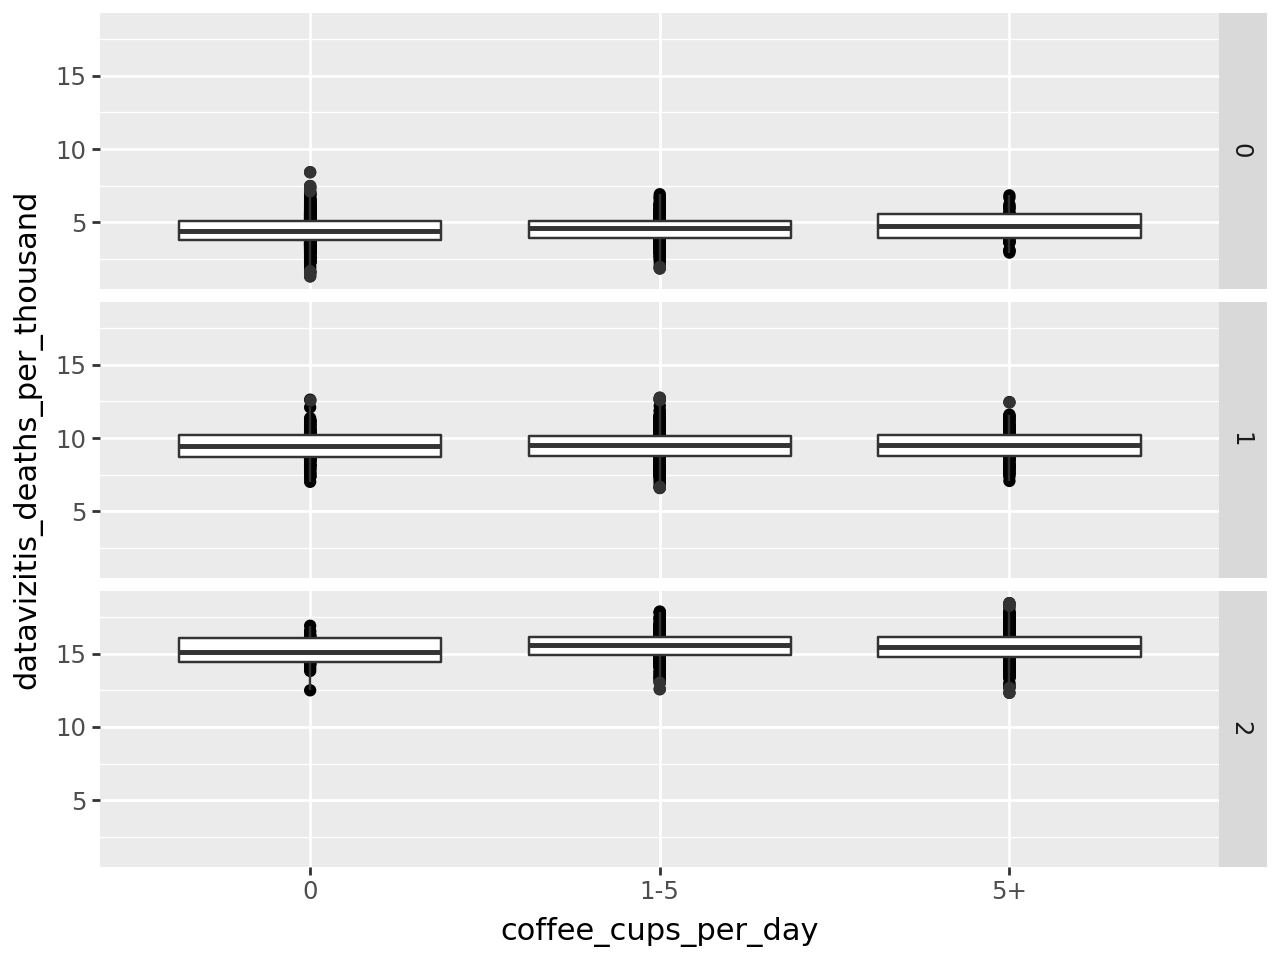

In [51]:
ggplot(coffee_dt, aes(y="datavizitis_deaths_per_thousand", x="coffee_cups_per_day")) + geom_point() + geom_boxplot() + facet_grid("cigarette_packs_per_day")

3. Draw a graph with the potential causal relationships you find consistent with the data. Relate it to
one of the situations from the lecture script’s figure 6.3 or Simpson’s paradox

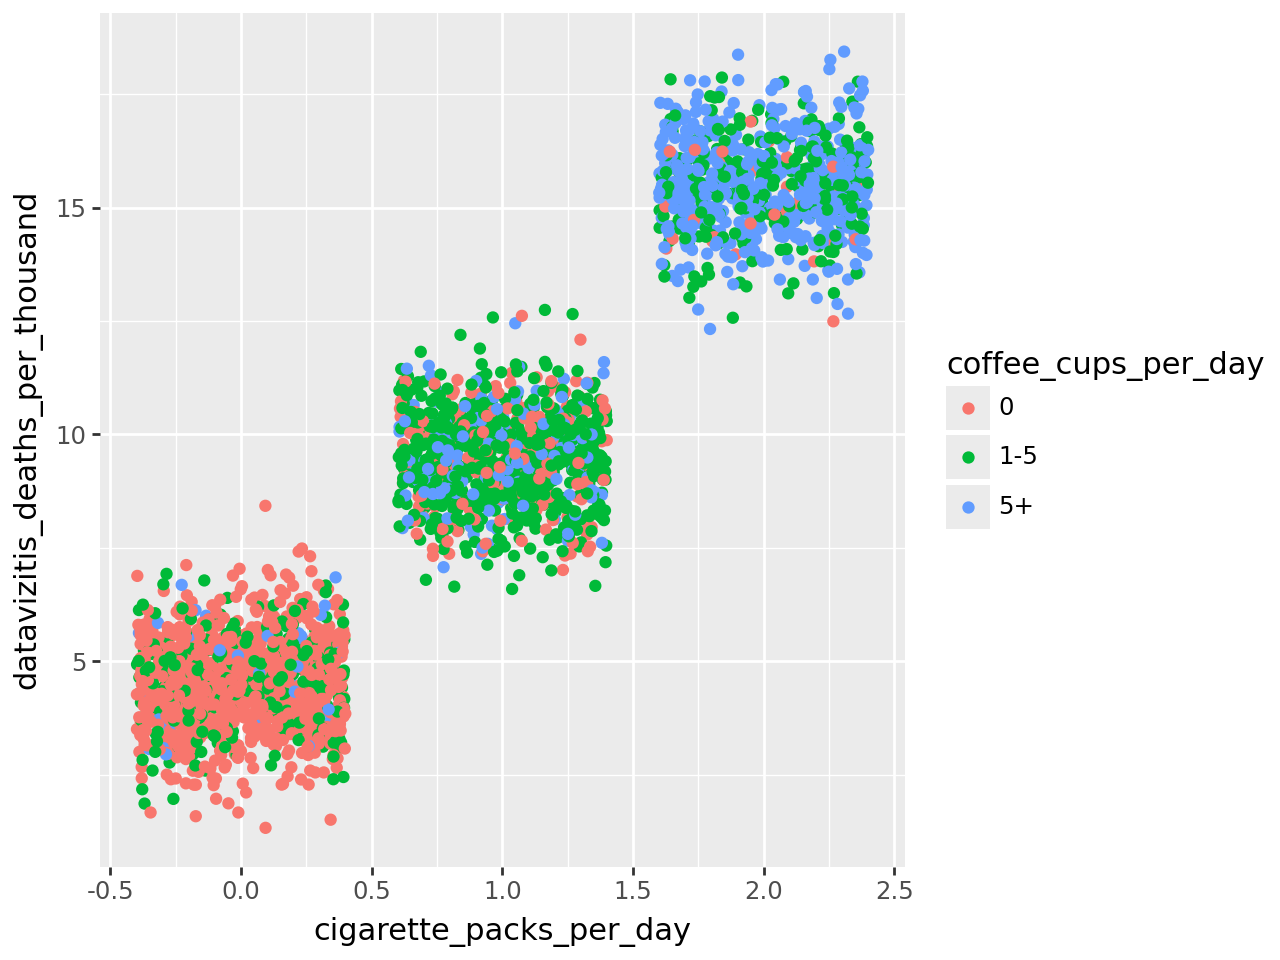

In [70]:
# Cigarettes influence death and coffee
ggplot(coffee_dt, aes(x="cigarette_packs_per_day", y="datavizitis_deaths_per_thousand", color="coffee_cups_per_day")) + geom_jitter()

# SMOKE causes both coffee cups per day and deaths per thousand

In biology, a wild type strain (WT) is a strain whose genome has not been artificially modified. In
contrast, a mutant is a strain whose genome has been artificially modified.
2. Implement the solution proposed by the tutor using the following simulated data that approximately
mimick the original data.

     pro_uptake mutants
0   9994.376826      WT
1  10169.285519      WT
2   9875.461247      WT
3  12546.600141    T49A
4  12328.290279    T49A


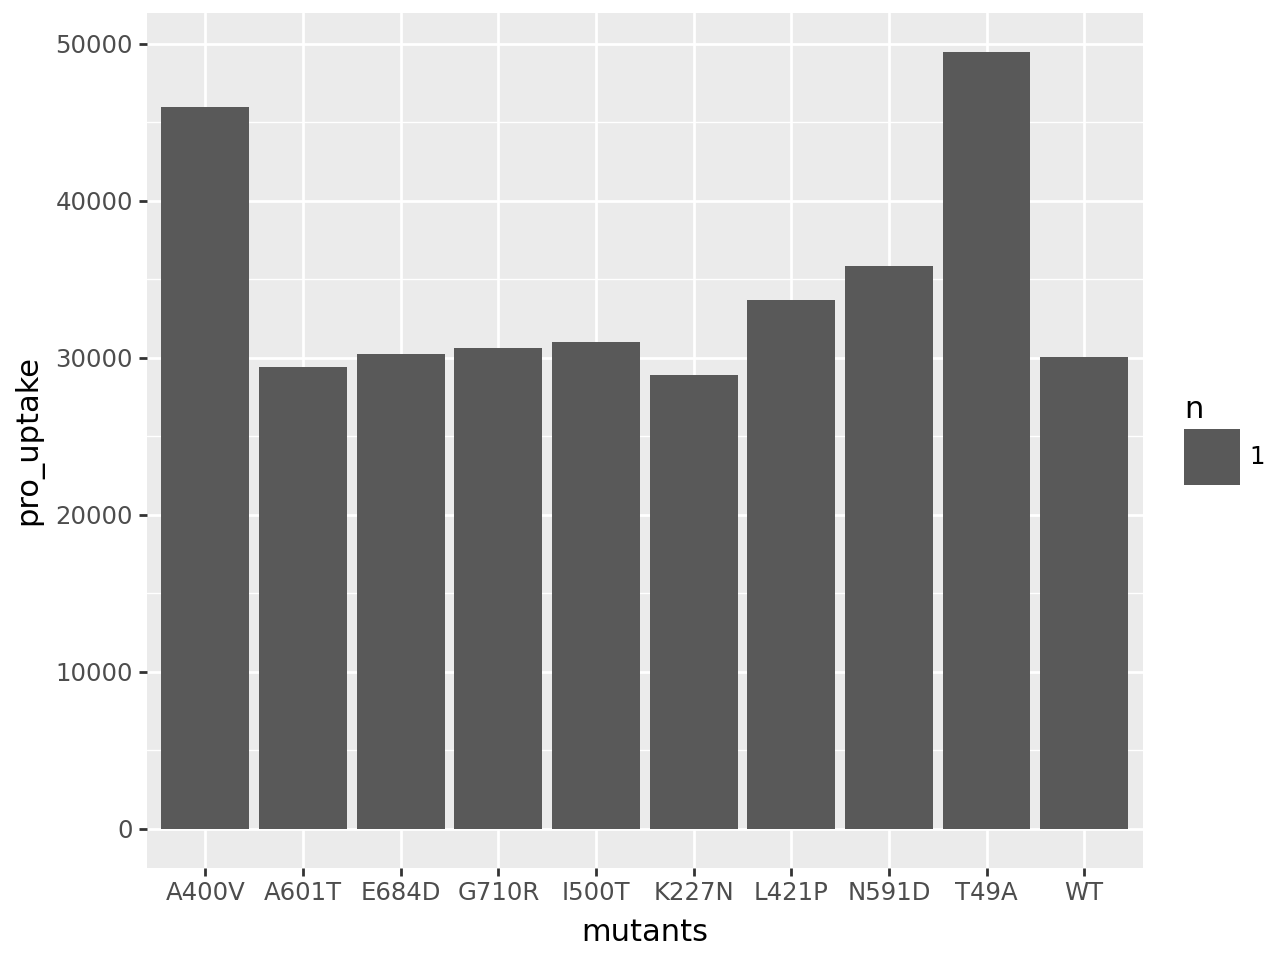

In [92]:
SIMULATION_GROUPS = [
(10100, 3, "WT"), (12100, 4, "T49A"), (9850, 3, "K227N"), (11100, 4, "A400V"),
(8300, 4, "L421P"), (10050, 3, "I500T"), (12000, 3, "N591D"),
(10020, 3, "A601T"), (10080, 3, "E684D"), (10070, 3, "G710R")
]
SCALE = 300
# Generate and concatenate data using list comprehensions
pro_uptake = np.concatenate([
np.random.normal(loc=loc, scale=SCALE, size=size) for loc, size, _ in SIMULATION_GROUPS
])
mutants = np.concatenate([
np.repeat(mutant, size) for _, size, mutant in SIMULATION_GROUPS
])
# Create the Pandas DataFrame
dt = pd.DataFrame({'pro_uptake': pro_uptake, 'mutants': mutants})
print(dt.head())

dt.groupby('mutants')
ggplot(dt, aes(x="mutants", y="pro_uptake")) + geom_count() + geom_bar(stat="sum") + geom_line(aes(y = 10100, x = "mutants"), color="red", size=5)